In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import Xception
from sklearn.model_selection import train_test_split

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


I0000 00:00:1774081637.200799    3546 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774081637.655127    3546 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774081639.869459    3546 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Image Resizing

In [3]:
import os

class_names = sorted(os.listdir("Images"))
print(class_names)

['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound', 'n02088238-basset', 'n02088364-beagle', 'n02088466-bloodhound', 'n02088632-bluetick', 'n02089078-black-and-tan_coonhound', 'n02089867-Walker_hound', 'n02089973-English_foxhound', 'n02090379-redbone', 'n02090622-borzoi', 'n02090721-Irish_wolfhound', 'n02091032-Italian_greyhound', 'n02091134-whippet', 'n02091244-Ibizan_hound', 'n02091467-Norwegian_elkhound', 'n02091635-otterhound', 'n02091831-Saluki', 'n02092002-Scottish_deerhound', 'n02092339-Weimaraner', 'n02093256-Staffordshire_bullterrier', 'n02093428-American_Staffordshire_terrier', 'n02093647-Bedlington_terrier', 'n02093754-Border_terrier', 'n02093859-Kerry_blue_terrier', 'n02093991-Irish_terrier', 'n02094114-Norfolk_terrier', 'n02094258-Norwich_terrier', 'n02094433-Yorkshire_t

In [14]:
os.mkdir("./data")
for breed in class_names:
    os.mkdir("./data/" + breed)

In [16]:
for breed in class_names:
    for file in os.listdir('./images/{}'.format(breed)):
        img = Image.open('./images/{}/{}'.format(breed, file))
        img = img.convert('RGB')
        img = img.resize((299, 299))
        img.save('./data/' + breed + '/' + file )

## Train, Validation, Test Split

In [4]:
def paths():
    paths = list()
    for breed in class_names:
        base_name = "./data/{}/".format(breed)
        for img_name in os.listdir(base_name):
            paths.append(base_name + img_name)
    return paths

paths = paths()

In [5]:
print(paths[:5])

['./data/n02085620-Chihuahua/n02085620_10074.jpg', './data/n02085620-Chihuahua/n02085620_10131.jpg', './data/n02085620-Chihuahua/n02085620_10621.jpg', './data/n02085620-Chihuahua/n02085620_1073.jpg', './data/n02085620-Chihuahua/n02085620_10976.jpg']


In [6]:
len(paths)

20580

### Train 80%, Validation 10%, Test 10%

In [9]:
train_paths, val_test_paths= train_test_split(paths, test_size=0.2, random_state=1029)
val_paths, test_paths = train_test_split(val_test_paths, test_size=0.5, random_state=1029)

In [32]:
os.mkdir("./dogs")

In [10]:
d = paths[0].split('/')[2]
print(d)

n02085620-Chihuahua


In [11]:
d = paths[0].split('/')[3]
print(d)

n02085620_10074.jpg


In [12]:
#dataset

def train_val_test_dataset(name, paths):
    os.mkdir('./dogs/' + name)
    for breed in class_names:
        os.mkdir('./dogs/'+ name + '/' + breed)
        
    for i in range(len(paths)):
        for breed in class_names:
             if (paths[i].split('/')[2] == breed):
                img = Image.open(paths[i])
                img.save('./dogs/'+ name + '/'+ breed + '/' + paths[i].split('/')[3] )


In [36]:
train_val_test_dataset('train', train_paths)

In [37]:
train_val_test_dataset('val', val_paths)

In [38]:
train_val_test_dataset('test', test_paths)

## Train, Val, Test Preprocessing Before model training

In [3]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds =  train_gen.flow_from_directory(
            'dogs/train',
            target_size=(150, 150),
            batch_size=128
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds =  val_gen.flow_from_directory(
         'dogs/val',
          target_size=(150, 150),
          batch_size=128,
          shuffle=False
)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    'dogs/test',
    target_size=(150, 150),
    batch_size=128,
    shuffle=False
)

Found 16464 images belonging to 120 classes.
Found 2058 images belonging to 120 classes.
Found 2058 images belonging to 120 classes.


## Model tuning for input shape 150

In [4]:
def make_model(learning_rate=0.01, size_inner=100):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )
    base_model.trainable = False

    ###########################################
    
    inputs = keras.Input(shape=(150, 150, 3))
    
    base = base_model(inputs, training=False)
    
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    
    outputs = keras.layers.Dense(120)(inner)
    
    model = keras.Model(inputs, outputs)

    ###########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

## Learning Rate Tuning with image size 150,150

In [6]:
scores = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history
    
    print()

0.0001
Epoch 1/10


I0000 00:00:1772991095.470720  150442 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_55242__.128


 36/129 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.0167 - loss: 4.8241

I0000 00:00:1772991105.533101  150442 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_55242__.128


129/129 ━━━━━━━━━━━━━━━━━━━━ 39s 233ms/step - accuracy: 0.1686 - loss: 4.1719 - val_accuracy: 0.3503 - val_loss: 3.3437
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 119ms/step - accuracy: 0.5005 - loss: 2.5444 - val_accuracy: 0.5569 - val_loss: 2.0722
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.6112 - loss: 1.7304 - val_accuracy: 0.6040 - val_loss: 1.6604
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - accuracy: 0.6435 - loss: 1.4526 - val_accuracy: 0.6113 - val_loss: 1.5123
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.6619 - loss: 1.3214 - val_accuracy: 0.6278 - val_loss: 1.4411
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - accuracy: 0.6734 - loss: 1.2394 - val_accuracy: 0.6356 - val_loss: 1.3901
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.6861 - loss: 1.1801 - val_accuracy: 0.6409 - val_loss: 1.3609
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.6925 - loss: 1.1334 - val_acc

...

129/129 ━━━━━━━━━━━━━━━━━━━━ 38s 223ms/step - accuracy: 0.5050 - loss: 2.0310 - val_accuracy: 0.5646 - val_loss: 1.7505
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - accuracy: 0.6030 - loss: 1.4871 - val_accuracy: 0.5661 - val_loss: 1.7760
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.6393 - loss: 1.3078 - val_accuracy: 0.5607 - val_loss: 1.8720
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.6722 - loss: 1.1580 - val_accuracy: 0.5617 - val_loss: 1.8974
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.6933 - loss: 1.0711 - val_accuracy: 0.5646 - val_loss: 2.0252
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.7083 - loss: 1.0020 - val_accuracy: 0.5520 - val_loss: 2.1656
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.7349 - loss: 0.9022 - val_accuracy: 0.5739 - val_loss: 2.2514
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - accuracy: 0.7592 - loss: 0.8006 - val_accurac

I0000 00:00:1772991547.892259  150442 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_102846__.128


 97/129 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.0172 - loss: 16.6938

I0000 00:00:1772991563.346015  150440 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_102846__.128


129/129 ━━━━━━━━━━━━━━━━━━━━ 39s 231ms/step - accuracy: 0.0150 - loss: 7.2614 - val_accuracy: 0.0112 - val_loss: 4.8549
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - accuracy: 0.0114 - loss: 4.8079 - val_accuracy: 0.0063 - val_loss: 4.8090
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.0093 - loss: 4.8026 - val_accuracy: 0.0083 - val_loss: 4.8003
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.0091 - loss: 4.8047 - val_accuracy: 0.0063 - val_loss: 4.8034
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step - accuracy: 0.0087 - loss: 4.8051 - val_accuracy: 0.0121 - val_loss: 4.8054
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - accuracy: 0.0097 - loss: 4.8062 - val_accuracy: 0.0078 - val_loss: 4.8137
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 130ms/step - accuracy: 0.0087 - loss: 4.8036 - val_accuracy: 0.0117 - val_loss: 4.7991
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - accuracy: 0.0104 - loss: 4.8024 - val

## Model tuning for input shape 299,299

In [9]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds =  train_gen.flow_from_directory(
            './dogs/train',
            target_size=(299, 299),
            batch_size=64
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds =  val_gen.flow_from_directory(
         './dogs/val',
          target_size=(299, 299),
          batch_size=64,
          shuffle=False
)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    './dogs/test',
    target_size=(299, 299),
    batch_size=64,
    shuffle=False
)

Found 16464 images belonging to 120 classes.
Found 2058 images belonging to 120 classes.
Found 2058 images belonging to 120 classes.


In [10]:
def make_model(learning_rate=0.01, size_inner=100):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(299, 299, 3)
    )
    base_model.trainable = False

    ###########################################
    
    inputs = keras.Input(shape=(299, 299, 3))
    
    base = base_model(inputs, training=False)
    
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    
    outputs = keras.layers.Dense(120)(inner)
    
    model = keras.Model(inputs, outputs)

    ###########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

## Learning Rate tuning for iamge size 299,299

In [11]:
scores = {}

for lr in [ 0.0001, 0.001, 0.01]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history
    
    print()
    print()

0.0001
Epoch 1/10


I0000 00:00:1773316305.857314     642 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_49565__.128
E0000 00:00:1773316313.008335     642 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


123/258 ━━━━━━━━━━━━━━━━━━━━ 18s 138ms/step - accuracy: 0.0703 - loss: 4.6443

I0000 00:00:1773316337.117989     640 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_49565__.128
E0000 00:00:1773316341.000672     640 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.1741 - loss: 4.4251

...

254/258 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.6883 - loss: 1.3360

I0000 00:00:1773317156.611335     640 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_92901__.128


258/258 ━━━━━━━━━━━━━━━━━━━━ 69s 227ms/step - accuracy: 0.7911 - loss: 0.7849 - val_accuracy: 0.8134 - val_loss: 0.6863
Epoch 2/10


W0000 00:00:1773317180.086707    5884 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 68690688 bytes after encountering the first element of size 68690688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


258/258 ━━━━━━━━━━━━━━━━━━━━ 38s 144ms/step - accuracy: 0.8610 - loss: 0.4608 - val_accuracy: 0.8231 - val_loss: 0.6885
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 37s 143ms/step - accuracy: 0.8744 - loss: 0.4100 - val_accuracy: 0.8328 - val_loss: 0.6253
Epoch 4/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 37s 144ms/step - accuracy: 0.8944 - loss: 0.3435 - val_accuracy: 0.8484 - val_loss: 0.6317
Epoch 5/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 36s 141ms/step - accuracy: 0.8999 - loss: 0.3277 - val_accuracy: 0.8465 - val_loss: 0.7222
Epoch 6/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 39s 152ms/step - accuracy: 0.9064 - loss: 0.3101 - val_accuracy: 0.8489 - val_loss: 0.7545
Epoch 7/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 40s 155ms/step - accuracy: 0.9174 - loss: 0.2675 - val_accuracy: 0.8401 - val_loss: 0.8207
Epoch 8/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 38s 146ms/step - accuracy: 0.9282 - loss: 0.2392 - val_accuracy: 0.8372 - val_loss: 0.8580
Epoch 9/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 35s 136ms/step - accuracy: 0.9237 - loss: 0.2482 - val

##  Choose input size(299,299,3) and learning rate 0.001

## Tuning the inner size 200

In [16]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds =  train_gen.flow_from_directory(
            './dogs/train',
            target_size=(299, 299),
            batch_size=64
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds =  val_gen.flow_from_directory(
         './dogs/val',
          target_size=(299, 299),
          batch_size=64,
          shuffle=False
)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    './dogs/test',
    target_size=(299, 299),
    batch_size=64,
    shuffle=False
)

Found 16464 images belonging to 120 classes.
Found 2058 images belonging to 120 classes.
Found 2058 images belonging to 120 classes.


In [4]:
def make_model(learning_rate=0.01, size_inner=100):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(299, 299, 3)
    )
    base_model.trainable = False

    ###########################################
    
    inputs = keras.Input(shape=(299, 299, 3))
    
    base = base_model(inputs, training=False)
    
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    
    outputs = keras.layers.Dense(120)(inner)
    
    model = keras.Model(inputs, outputs)

    ###########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [7]:
learning_rate = 0.0001

scores = {}

for size in [200]:
    print(size)

    model = make_model(learning_rate=learning_rate, size_inner=size)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history
    
    print()
    print()

200
Epoch 1/10


I0000 00:00:1773320496.248779   10045 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40921__.128


218/258 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.2682 - loss: 4.2616

I0000 00:00:1773320531.162152   10045 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40921__.128


258/258 ━━━━━━━━━━━━━━━━━━━━ 64s 220ms/step - accuracy: 0.5419 - loss: 3.3965 - val_accuracy: 0.8100 - val_loss: 1.9121
Epoch 2/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 35s 134ms/step - accuracy: 0.8684 - loss: 1.1168 - val_accuracy: 0.8756 - val_loss: 0.7416
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 37s 144ms/step - accuracy: 0.8933 - loss: 0.5659 - val_accuracy: 0.8868 - val_loss: 0.5145
Epoch 4/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 37s 144ms/step - accuracy: 0.9003 - loss: 0.4294 - val_accuracy: 0.8897 - val_loss: 0.4319
Epoch 5/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 37s 144ms/step - accuracy: 0.9052 - loss: 0.3681 - val_accuracy: 0.8941 - val_loss: 0.3921
Epoch 6/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 37s 143ms/step - accuracy: 0.9080 - loss: 0.3332 - val_accuracy: 0.8989 - val_loss: 0.3693
Epoch 7/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 35s 143ms/step - accuracy: 0.9131 - loss: 0.3074 - val_accuracy: 0.8965 - val_loss: 0.3518
Epoch 8/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 37s 143ms/step - accuracy: 0.9155 - loss: 0.2885 - val

## Droprate tuning

In [17]:
def make_model(input_size=299, learning_rate=0.0001, size_inner=200,
               droprate=0.5):

    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(input_size, input_size, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(input_size, input_size, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)
    
    outputs = keras.layers.Dense(120)(drop)
    
    model = keras.Model(inputs, outputs)
    
    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    
    return model

In [10]:
learning_rate = 0.0001
size = 200
scores = {}

for droprate in [0.0, 0.2, 0.5]:
    print(droprate)

    model = make_model(learning_rate=learning_rate, size_inner=size, droprate=droprate)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[droprate] = history.history
    
    print()
    print()

0.0
Epoch 1/10


I0000 00:00:1773321147.427024   10041 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_62589__.128


114/258 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - accuracy: 0.1364 - loss: 4.5507

I0000 00:00:1773321166.667903   10042 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_62589__.128


258/258 ━━━━━━━━━━━━━━━━━━━━ 63s 208ms/step - accuracy: 0.5384 - loss: 3.3664 - val_accuracy: 0.8158 - val_loss: 1.8702
Epoch 2/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 38s 146ms/step - accuracy: 0.8683 - loss: 1.1016 - val_accuracy: 0.8814 - val_loss: 0.7402
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 35s 135ms/step - accuracy: 0.8934 - loss: 0.5653 - val_accuracy: 0.8878 - val_loss: 0.5137
Epoch 4/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 38s 146ms/step - accuracy: 0.8992 - loss: 0.4305 - val_accuracy: 0.8921 - val_loss: 0.4341
Epoch 5/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 38s 146ms/step - accuracy: 0.9054 - loss: 0.3682 - val_accuracy: 0.8989 - val_loss: 0.3921
Epoch 6/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 38s 146ms/step - accuracy: 0.9098 - loss: 0.3332 - val_accuracy: 0.9028 - val_loss: 0.3689
Epoch 7/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 38s 145ms/step - accuracy: 0.9131 - loss: 0.3079 - val_accuracy: 0.8980 - val_loss: 0.3539
Epoch 8/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 35s 136ms/step - accuracy: 0.9164 - loss: 0.2886 - val

...

 14/258 ━━━━━━━━━━━━━━━━━━━━ 36s 148ms/step - accuracy: 0.0084 - loss: 4.8225

I0000 00:00:1773321952.733942   10041 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_106099__.129


258/258 ━━━━━━━━━━━━━━━━━━━━ 64s 211ms/step - accuracy: 0.3059 - loss: 3.8843 - val_accuracy: 0.7478 - val_loss: 2.6489
Epoch 2/10


W0000 00:00:1773322004.445770   15032 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 68690688 bytes after encountering the first element of size 68690688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


258/258 ━━━━━━━━━━━━━━━━━━━━ 38s 145ms/step - accuracy: 0.6880 - loss: 2.0068 - val_accuracy: 0.8659 - val_loss: 1.1693
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 35s 135ms/step - accuracy: 0.7802 - loss: 1.1669 - val_accuracy: 0.8810 - val_loss: 0.7037
Epoch 4/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 37s 145ms/step - accuracy: 0.8119 - loss: 0.8554 - val_accuracy: 0.8858 - val_loss: 0.5398
Epoch 5/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 38s 146ms/step - accuracy: 0.8319 - loss: 0.7159 - val_accuracy: 0.8868 - val_loss: 0.4659
Epoch 6/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 37s 145ms/step - accuracy: 0.8414 - loss: 0.6234 - val_accuracy: 0.8902 - val_loss: 0.4237
Epoch 7/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 35s 135ms/step - accuracy: 0.8496 - loss: 0.5637 - val_accuracy: 0.8902 - val_loss: 0.3948
Epoch 8/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 38s 146ms/step - accuracy: 0.8582 - loss: 0.5272 - val_accuracy: 0.8931 - val_loss: 0.3804
Epoch 9/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 38s 145ms/step - accuracy: 0.8669 - loss: 0.4904 - val

## Overfitting and Underfitting Analysis

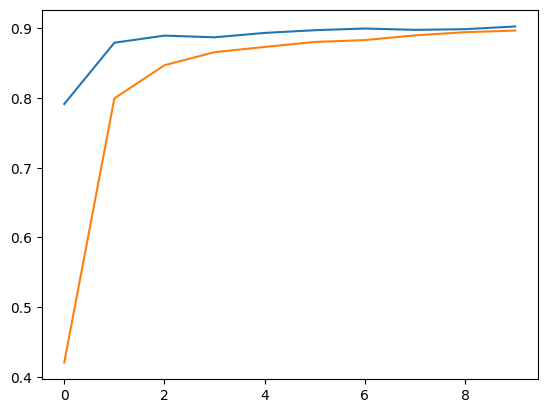

In [23]:
hist = scores[0.2]
plt.plot(hist['val_accuracy'], label=('val=%s' %droprate))
plt.plot(hist['accuracy'], label=('val=%s' %droprate))

## Final Model Image Preprocessing

In [35]:
input_size=299

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

train_ds = train_gen.flow_from_directory(
    './dogs/train',
    target_size=(input_size, input_size),
    batch_size=64
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './dogs/val',
    target_size=(input_size, input_size),
    batch_size=64,
    shuffle=False
)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    './dogs/test',
    target_size=(input_size, input_size),
    batch_size=16,
    shuffle=False
)

Found 16464 images belonging to 120 classes.
Found 2058 images belonging to 120 classes.
Found 2058 images belonging to 120 classes.


## Final Model

In [ ]:
def make_model(input_size=299, learning_rate=0.0001, size_inner=200,
               droprate=0.2):

    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(input_size, input_size, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(input_size, input_size, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)
    
    outputs = keras.layers.Dense(120)(drop)
    
    model = keras.Model(inputs, outputs)
    
    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    
    return model

In [37]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v6_1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

## Final Model Training with Epochs 30 and saving the best one

In [38]:
input_size=299
learning_rate = 0.0001
size = 200
droprate=0.2

model = make_model(
    input_size=input_size,
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=30, validation_data=val_ds,
                   callbacks=[checkpoint])

Epoch 1/30


I0000 00:00:1773397732.900662     672 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_29889__.129


184/258 ━━━━━━━━━━━━━━━━━━━━ 48s 654ms/step - accuracy: 0.1713 - loss: 4.4578

I0000 00:00:1773397859.918767     672 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_29889__.129


258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.2363 - loss: 4.2764

...

258/258 ━━━━━━━━━━━━━━━━━━━━ 181s 702ms/step - accuracy: 0.8900 - loss: 0.3758 - val_accuracy: 0.8999 - val_loss: 0.3455
Epoch 10/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 176s 681ms/step - accuracy: 0.8922 - loss: 0.3656 - val_accuracy: 0.8994 - val_loss: 0.3358
Epoch 11/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.8927 - loss: 0.3498

258/258 ━━━━━━━━━━━━━━━━━━━━ 171s 661ms/step - accuracy: 0.8908 - loss: 0.3558 - val_accuracy: 0.9014 - val_loss: 0.3361
Epoch 12/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.8995 - loss: 0.3272

258/258 ━━━━━━━━━━━━━━━━━━━━ 184s 711ms/step - accuracy: 0.8959 - loss: 0.3417 - val_accuracy: 0.9023 - val_loss: 0.3294
Epoch 13/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.8982 - loss: 0.3335

258/258 ━━━━━━━━━━━━━━━━━━━━ 175s 677ms/step - accuracy: 0.8982 - loss: 0.3306 - val_accuracy: 0.9048 - val_loss: 0.3242
Epoch 14/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 179s 692ms/step - accuracy: 0.9014 - loss: 0.3254 - val_accuracy: 0.9004 - val_loss: 0.3244
Epoch 15/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 171s 661ms/step - accuracy: 0.9018 - loss: 0.3094 - val_accuracy: 0.9014 - val_loss: 0.3230
Epoch 16/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9034 - loss: 0.3136

258/258 ━━━━━━━━━━━━━━━━━━━━ 173s 669ms/step - accuracy: 0.9039 - loss: 0.3090 - val_accuracy: 0.9057 - val_loss: 0.3200
Epoch 17/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 168s 652ms/step - accuracy: 0.9057 - loss: 0.2975 - val_accuracy: 0.9018 - val_loss: 0.3163
Epoch 18/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 182s 706ms/step - accuracy: 0.9093 - loss: 0.2896 - val_accuracy: 0.9057 - val_loss: 0.3186
Epoch 19/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 179s 694ms/step - accuracy: 0.9080 - loss: 0.2862 - val_accuracy: 0.9052 - val_loss: 0.3183
Epoch 20/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 181s 703ms/step - accuracy: 0.9112 - loss: 0.2801 - val_accuracy: 0.9028 - val_loss: 0.3162
Epoch 21/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 177s 684ms/step - accuracy: 0.9119 - loss: 0.2754 - val_accuracy: 0.9052 - val_loss: 0.3133
Epoch 22/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 181s 699ms/step - accuracy: 0.9142 - loss: 0.2686 - val_accuracy: 0.9009 - val_loss: 0.3122
Epoch 23/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 174s 674ms/step - accuracy: 0.9177 - los

# Testing

In [4]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    './dogs/test',
    target_size=(299, 299),
    batch_size=16,
    shuffle=False
)

Found 2058 images belonging to 120 classes.


### Model Reloading

In [5]:
model = keras.models.load_model('xception_v6_1_30_0.906.h5')

W0000 00:00:1774081652.176170    3546 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1774081652.179457    3546 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1774081652.347702    3546 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13270 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


### Testing the Test data set

In [7]:
loss, accuracy = model.evaluate(test_ds)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8965 - loss: 0.3486
Test Loss: 0.3486
Test Accuracy: 0.8965


In [10]:
preds = model.predict(test_ds, verbose=1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step


In [11]:
y_pred = np.argmax(preds, axis=1)

In [12]:
y_true = test_ds.classes

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

                                          precision    recall  f1-score   support

                     n02085620-Chihuahua       0.72      1.00      0.84        13
              n02085782-Japanese_spaniel       0.94      0.85      0.89        20
                   n02085936-Maltese_dog       0.93      0.96      0.94        26
                      n02086079-Pekinese       0.78      0.88      0.82        16
                      n02086240-Shih-Tzu       0.73      0.85      0.79        26
              n02086646-Blenheim_spaniel       0.94      1.00      0.97        17
                      n02086910-papillon       1.00      0.89      0.94        18
                   n02087046-toy_terrier       1.00      0.63      0.77        19
           n02087394-Rhodesian_ridgeback       0.59      1.00      0.74        10
                  n02088094-Afghan_hound       1.00      1.00      1.00        27
                        n02088238-basset       0.93      0.87      0.90        15
               

### Testing with one image

In [8]:
path = './dogs/test/n02093991-Irish_terrier/n02093991_3807.jpg'
img = load_img(path, target_size=(299, 299))

x = np.array(img)
X = np.array([x])
X.shape

X = preprocess_input(X)
pred = model.predict(X)

E0000 00:00:1774081727.308185    3830 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
W0000 00:00:1774081728.072729    4649 hlo_rematerialization.cc:3204] Can't reduce memory use below 12.10GiB (12992575118 bytes) by rematerialization; only reduced to 16.71GiB (17947899472 bytes), down from 16.71GiB (17947899472 bytes) originally
W0000 00:00:1774081738.473770    3830 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.71GiB (rounded to 17943913472)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1774081738.473950    3830 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1774081738.473961    3830 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step


[('Irish terrier', np.float32(99.737404)), ('Norfolk terrier', np.float32(0.24060945)), ('vizsla', np.float32(0.005473723))]


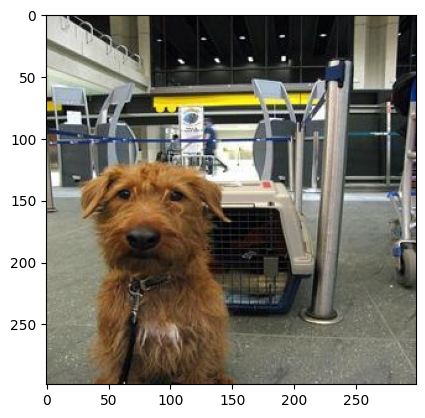

In [9]:
# convert logits → probabilities
prob = tf.nn.softmax(pred[0]).numpy()

# get top 3 indices
top3 = np.argsort(prob)[-3:][::-1]

results = []

for i in top3:
    raw_name = class_names[i]

    # remove WordNet id and format name
    dog_name = raw_name.split("-")[1].replace("_"," ")

    confidence = prob[i] * 100

    results.append((dog_name, confidence))

plt.imshow(img)
print(results)